In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV , StratifiedKFold 
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import  ColumnTransformer, make_column_transformer, make_column_selector
from sklearn.metrics import r2_score, log_loss, accuracy_score, roc_auc_score, f1_score, log_loss

from sklearn.tree import DecisionTreeRegressor, plot_tree, DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, LinearRegression, ElasticNet, Ridge
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.svm import SVC
from xgboost import XGBClassifier, XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer 
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, StackingClassifier, StackingRegressor, VotingClassifier, VotingRegressor

from sklearn.manifold import TSNE #**

from tqdm import tqdm  # Provides the progress of model running
import os
os.chdir("D:/Machine_Learning/")
import warnings
warnings.filterwarnings('ignore')

In [2]:
cancer = pd.read_csv("Cases/Wisconsin/BreastCancer.csv", index_col=0)
X, y = cancer.drop("Class", axis=1), cancer["Class"]
tsne = TSNE(random_state=26).set_output(transform="pandas")
X_tsne = tsne.fit_transform(X)
tsne_data = pd.concat([X_tsne, y], axis=1)
tsne_data.columns

Index(['tsne0', 'tsne1', 'Class'], dtype='str')

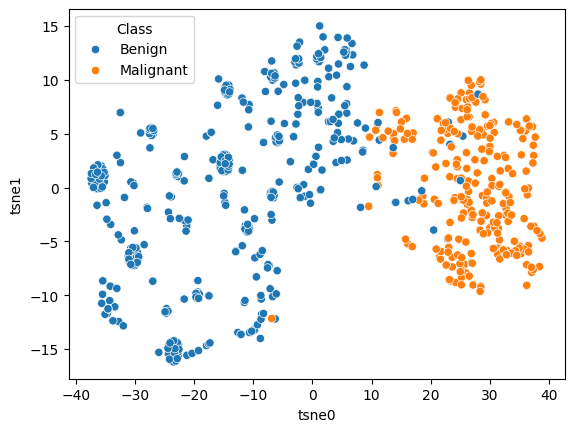

In [3]:
sns.scatterplot(data=tsne_data, x="tsne0", y="tsne1", hue="Class")
plt.show()

# Solar Dataset

In [4]:
sonar = pd.read_csv("Cases/Sonar/sonar.csv")
X, y = sonar.drop("Class", axis=1), sonar["Class"]
tsne = TSNE(random_state=26).set_output(transform="pandas")
X_tsne = tsne.fit_transform(X)
tsne_data = pd.concat([X_tsne, y], axis=1)
tsne_data.columns

Index(['tsne0', 'tsne1', 'Class'], dtype='str')

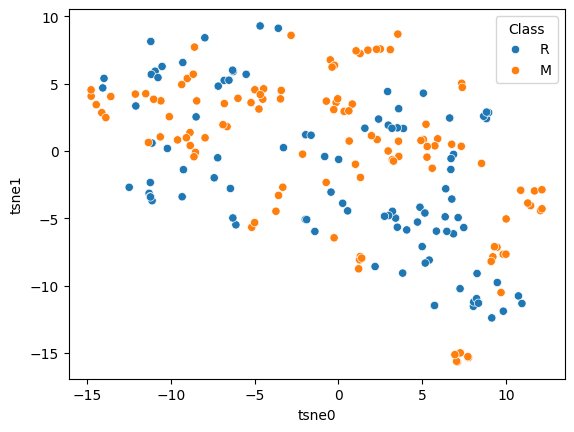

In [5]:
sns.scatterplot(data=tsne_data, x="tsne0", y="tsne1", hue="Class")
plt.show()

In [6]:
sonar.shape

(208, 61)

## Irrigation Need

In [7]:
train = pd.read_csv("C:/Users/PGCP-AI/Downloads/IrrigationKaggle/train.csv", index_col=0)
test = pd.read_csv("C:/Users/PGCP-AI/Downloads/IrrigationKaggle/test.csv", index_col=0)
X_train, y_train = train.drop("Irrigation_Need", axis=1), train["Irrigation_Need"]

scaler = StandardScaler()

ohe=OneHotEncoder(sparse_output=False,drop="first").set_output(transform="pandas")

trans = ColumnTransformer(transformers=[("OHE", ohe, make_column_selector(dtype_include=object)), ("SCL", scaler, make_column_selector(dtype_exclude=object))],     
                          remainder="passthrough",verbose_feature_names_out=False).set_output(transform="pandas")

X_trn_ohe_scl = trans.fit_transform(X_train)
X_tst_ohe_scl = trans.transform(test)




In [ ]:
tsne = TSNE(random_state=26, perplexity=50 ).set_output(transform="pandas")
X_tsne = tsne.fit_transform(X_trn_ohe_scl)
tsne_data = pd.concat([X_tsne, test], axis=1)
tsne_data.columns

In [9]:
sns.scatterplot(data=tsne_data, x="tsne0", y="tsne1", hue="Class")
plt.show()

ValueError: Could not interpret value `Class` for `hue`. An entry with this name does not appear in `data`.

In [ ]:
train